In [2]:
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import bisect


# updated src file changes are loaded
%load_ext autoreload
%autoreload 2

sys.path.append(os.path.abspath(".."))

In [3]:


def compute_force(speed, objectArea, dragCoefficient, mediumDensity):
    return 0.5 * dragCoefficient * mediumDensity * (objectArea/2) * (speed * speed)

def apply_water_current_force(velocity, areaBall, CdWater, rhoWater, waterSpeed, massBall, dt):
    direction = 1.0 if waterSpeed >= 0.0 else -1.0
    
    water_force = compute_force(abs(waterSpeed), areaBall, CdWater, rhoWater)
    total_force = 0.5 * water_force
    
    acc = total_force / massBall
    delta_speed = acc * dt
    
    # Adds to X velocity based on water current direction
    velocity[0] += delta_speed * direction
    
    return velocity

def calculate_deceleration(velocity, areaBall, CdWater, rhoWater, massBall, dt):
    velocity_magnitude = np.linalg.norm(velocity)
    
    if velocity_magnitude == 0: # i.e., ball has stopped
        return velocity

    # drag forces
    drag_water = compute_force(velocity_magnitude, areaBall, CdWater, rhoWater)

    # Drag applied to half of the ball area
    total_drag_force = 0.5 * drag_water

    deceleration = total_drag_force / massBall
    delta_speed = deceleration * dt
    
    new_speed = max(velocity_magnitude - delta_speed, 0.0)

    # normalized velocity (scales len to 1.0)
    return (velocity / velocity_magnitude) * new_speed


def solution_space_angles_speed(water_speed, target_x_pos, target_z_pos):
    # Constants
    CdWater = 0.47
    rhoWater = 1000.0
    massBall = 1.0
    # radius is (0.5 m * 0.0999999) in Unity
    radiusBall = 0.049999995 
    areaBall = np.pi * (radiusBall ** 2)
    # 72Hz VR physics rate
    dt = 1.0 / 72.0 #

    def get_signed_error(launch_speed, angle_deg):
        angle_rad = np.radians(angle_deg)
        
        # Unity Coordinate Mapping (throw is in the XZ plane)
        velocity = np.array([launch_speed * np.cos(angle_rad), 0.0, launch_speed * np.sin(angle_rad)])
        position = np.array([0.0, 0.0, 0.0])
        
        while position[2] < target_z_pos:            
            # 1. ApplyWaterCurrentForce()
            velocity = apply_water_current_force(velocity, areaBall, CdWater, rhoWater, water_speed, massBall, dt)
            # 2. Update Position
            position += velocity * dt
            # Safety break: beyond target Z or out of bounds...
            if position[2] > 3.0 or abs(position[0]) > 5.0:
                break
            # 3. CalculateDeceleration()
            if np.linalg.norm(velocity) > 0.0: # if ball is moving (i.e., has a velcoity)...
                velocity = calculate_deceleration(velocity, areaBall, CdWater, rhoWater, massBall, dt)
                
        return position[0] - target_x_pos

    # THE SEARCH LOOP    
    angles = np.linspace(20, 130, 110) 
    normative_speeds = []

    for theta in angles:
        try:
            v_perfect = bisect(get_signed_error, 0.5, 7.0, args=(theta,))
            normative_speeds.append(v_perfect)
        except ValueError:
            normative_speeds.append(np.nan)

    df_normative = pd.DataFrame({
        "launch_angle_deg": angles,
        "normative_speed_m_s": normative_speeds
    })
    
    return df_normative

--- Running target X position: -0.6 ---
--- Running target X position: -0.3 ---
--- Running target X position: 0.3 ---
--- Running target X position: 0.6 ---


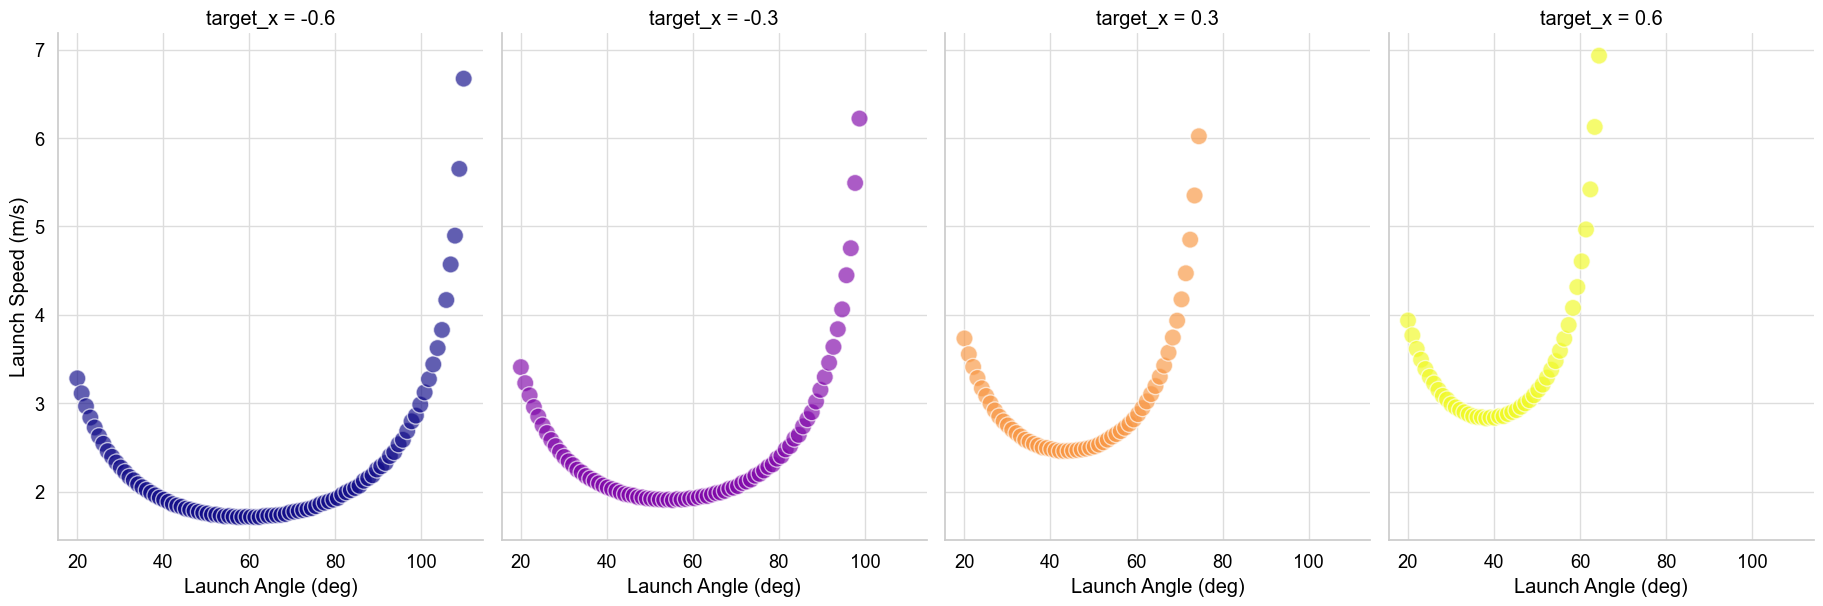

In [6]:

target_x_list = [-0.6, -0.3, 0.3, 0.6]

results_list = []

for tx in target_x_list:
    
    print(f'--- Running target X position: {tx} ---')

    # run function
    t = solution_space_angles_speed(-2.0, tx, 1.4)
    t['target_x'] = tx
    # store data
    results_list.append(t)

# save results into df, dropping NAs
res = pd.concat(results_list, ignore_index=True).dropna().reset_index(drop=True)

# plot
from src.plotting import plot_heatmap
plot_heatmap(res,
                     x_col = 'launch_angle_deg',
                     y_col='normative_speed_m_s',
                     colour_col='target_x',
                     mode='correlation', 
                     facet_col='target_x',
                     facet_row=None,
                     dark=False,
                     x_col_title = 'Launch Angle (deg)',
                     y_col_title = 'Launch Speed (m/s)')



--- Running target X position: -0.6 ---
--- Running target X position: -0.3 ---
--- Running target X position: 0.3 ---
--- Running target X position: 0.6 ---


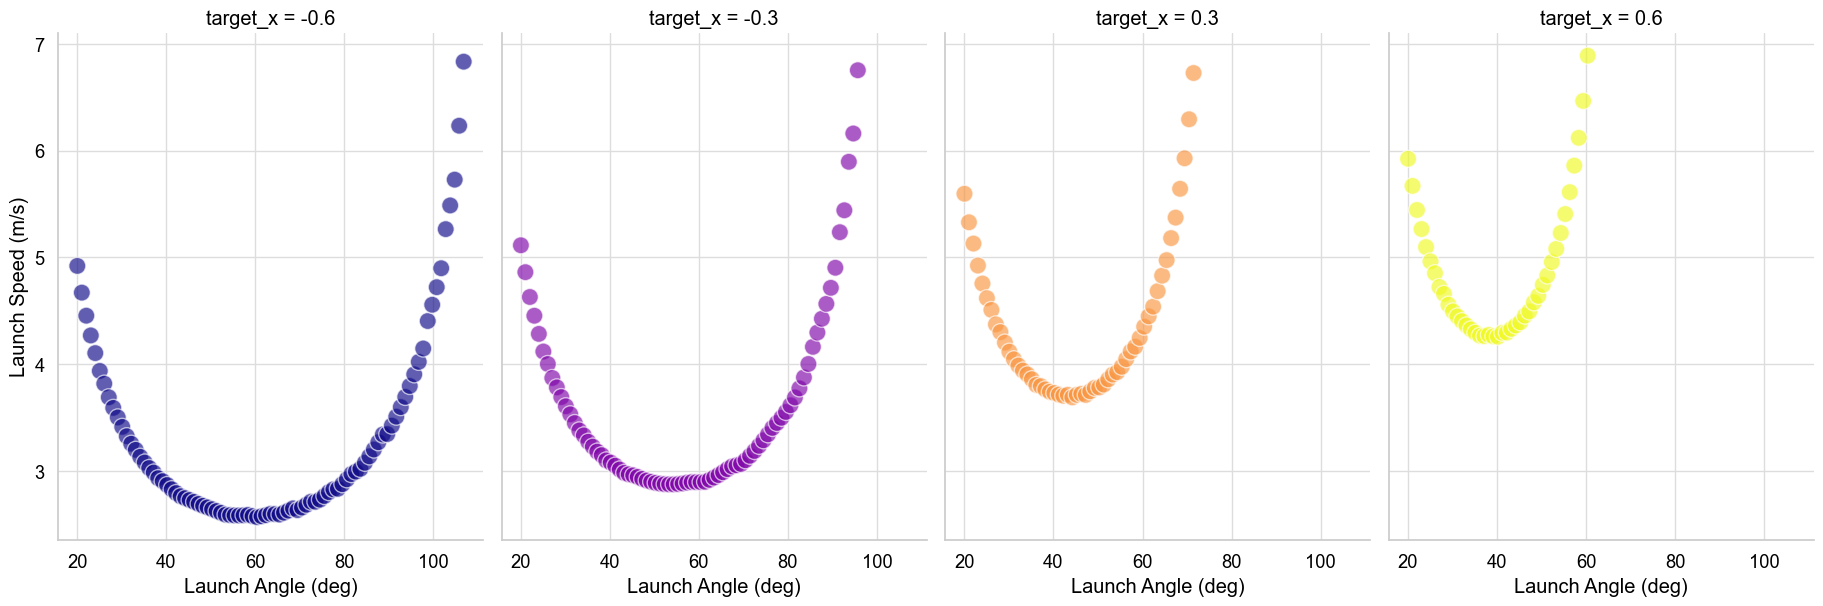

In [8]:

target_x_list = [-0.6, -0.3, 0.3, 0.6]

results_list = []

for tx in target_x_list:
    
    print(f'--- Running target X position: {tx} ---')

    # run function
    t = solution_space_angles_speed(-3.0, tx, 1.4)
    t['target_x'] = tx
    # store data
    results_list.append(t)

# save results into df, dropping NAs
res = pd.concat(results_list, ignore_index=True).dropna().reset_index(drop=True)

from src.plotting import plot_heatmap
plot_heatmap(res,
                     x_col = 'launch_angle_deg',
                     y_col='normative_speed_m_s',
                     colour_col='target_x',
                     mode='correlation', 
                     facet_col='target_x',
                     facet_row=None,
                     dark=False,
                     x_col_title = 'Launch Angle (deg)',
                     y_col_title = 'Launch Speed (m/s)')

